# RQ7 — Absolute vs Within-Scan Relative Representation

## Research question

> Does true-gate ranking generalise better across passwords when the model retains absolute acoustic identity, or when every 10-candidate scan is converted to a within-scan relative representation?

RQ6 showed that contextual acoustic information can contain both transferable structure and password-dependent shortcuts. RQ7 tests a related representation-level concern: a model may exploit absolute amplitude, spectral level or other stable acoustic fingerprints instead of the relative event that distinguishes one candidate from the other nine.

### Data

- Dataset v1 **B01–B07**
- passwords: **2085, 4369, 5720, 6893, 7246, 8451, 9638**
- wheels: **W1, W2 and W4**
- directions: **CCW and CW**
- A/B repeats retained as separate scan observations
- **840 decisions / 8,400 one-digit candidates**

### Controlled comparison

Everything except the input representation is held fixed.

**Absolute**

The recovered 695-D full-movement acoustic feature vector is used directly, followed by a `StandardScaler` fitted on the training passwords only.

**Relative**

Within each 10-candidate decision, every feature is centred by that scan's median and divided by `1.4826 × MAD`; standard deviation is used only when MAD is effectively zero. Values are clipped to `[-12, 12]`, followed by the same training-fold `StandardScaler`.

No labels are used in the within-scan normalisation.

### Evaluation

The split is **leave-one-password-out (LOPO)**. For every fold, models are fitted separately for each wheel × direction domain:

- W1 CCW / CW
- W2 CCW / CW
- W4 CCW / CW

The classifier is fixed logistic regression (`C=0.10`, balanced classes). It only provides a candidate score; the scientific outcome is the rank of the true digit among the ten candidates.

Primary metric: **Top-1 accuracy on the held-out password**.

The seven held-out passwords are the inferential units for the primary paired comparison. This is an RQ7 representation ablation, not MAIN-model performance.

## 1. Paths and fixed configuration

In [43]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import zipfile
import json

import numpy as np
import pandas as pd
from IPython.display import display

from scipy.stats import wilcoxon
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

MYDRIVE = Path("/content/drive/MyDrive")
DATASET_ROOT = MYDRIVE / "dataset"
PROJECT_ROOT = MYDRIVE / "Padlock_Reproduction_v1"

results_candidates = [
    PROJECT_ROOT / "results",
    PROJECT_ROOT / "Padlock_Reproduction_v1" / "results",
]

RESULTS_ROOT = next(
    (
        p for p in results_candidates
        if (p / "feature_cache").exists()
    ),
    None,
)

if RESULTS_ROOT is None:
    raise FileNotFoundError(
        "Could not locate Padlock_Reproduction_v1/results."
    )

DECISION_ROOT = DATASET_ROOT / "decision_batches"
CACHE_DIR = RESULTS_ROOT / "feature_cache"
RESULT_DIR = RESULTS_ROOT / "07_RQ7_Absolute_vs_Relative"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

BATCHES = [
    "B01_2085",
    "B02_4369",
    "B03_5720",
    "B04_6893",
    "B05_7246",
    "B06_8451",
    "B07_9638",
]

WHEELS = (1, 2, 4)
DIRECTIONS = ("CCW", "CW")

RANDOM_STATE = 20260819
LOGREG_C = 0.10
CLIP_RELATIVE = 12.0

print("Decision data :", DECISION_ROOT)
print("Feature cache :", CACHE_DIR)
print("RQ7 results   :", RESULT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Decision data : /content/drive/MyDrive/dataset/decision_batches
Feature cache : /content/drive/MyDrive/Padlock_Reproduction_v1/results/feature_cache
RQ7 results   : /content/drive/MyDrive/Padlock_Reproduction_v1/results/07_RQ7_Absolute_vs_Relative


## 2. Reconstruct the candidate manifest

The preserved decision JSON is the source of truth for wheel, direction, repeat, physical digit and true digit. The helper accepts either the extracted batch folders or the small decision-batch ZIP files.

In [44]:
def iter_decisions(batch):
    batch_dir = DECISION_ROOT / batch

    if batch_dir.exists():
        paths = sorted(
            batch_dir.glob("*/decision.json")
        )

        if len(paths) == 120:
            for path in paths:
                with open(
                    path,
                    "r",
                    encoding="utf-8",
                ) as f:
                    yield json.load(f)

            return

    batch_zip = DECISION_ROOT / f"{batch}.zip"

    if not batch_zip.exists():
        raise FileNotFoundError(
            f"Neither {batch_dir} nor {batch_zip} contains the decision data."
        )

    with zipfile.ZipFile(
        batch_zip
    ) as z:
        names = sorted(
            name
            for name in z.namelist()
            if name.endswith("/decision.json")
        )

        if len(names) != 120:
            raise RuntimeError(
                f"{batch}: expected 120 decisions, found {len(names)}"
            )

        for name in names:
            yield json.loads(
                z.read(name)
            )


manifest_rows = []

for batch in BATCHES:
    decisions = list(
        iter_decisions(batch)
    )

    if len(decisions) != 120:
        raise RuntimeError(
            f"{batch}: expected 120 decisions."
        )

    for d in decisions:
        wheel = int(
            d["active_wheels"][0]
        )

        direction = str(
            d["direction"]
        )

        repeat_id = str(
            d["repeat_id"]
        )

        profile_id = str(
            d["profile_id"]
        )

        decision_key = str(
            d["decision_key"]
        )

        true_digit = int(
            d["true_digits"][
                wheel - 1
            ]
        )

        digits = []

        for ordinal, candidate in enumerate(
            d["candidates"],
            start=1,
        ):
            status = str(
                candidate.get("status")
                or "VALID"
            ).upper()

            if status != "VALID":
                raise RuntimeError(
                    (
                        batch,
                        decision_key,
                        ordinal,
                        status,
                    )
                )

            run_id = str(
                candidate["run_id"]
            ).strip()

            to_digit = int(
                candidate["to_digit"]
            )

            digits.append(
                to_digit
            )

            manifest_rows.append({
                "batch": batch,
                "password": batch.split(
                    "_",
                    1,
                )[1],
                "decision_uid": (
                    f"{batch}/{decision_key}"
                ),
                "decision_key": decision_key,
                "profile_id": profile_id,
                "wheel": wheel,
                "direction": direction,
                "repeat_id": repeat_id,
                "candidate_ordinal": ordinal,
                "run_id": run_id,
                "to_digit": to_digit,
                "true_digit": true_digit,
                "y": int(
                    to_digit
                    == true_digit
                ),
            })

        if sorted(digits) != list(
            range(10)
        ):
            raise RuntimeError(
                (
                    batch,
                    decision_key,
                    digits,
                )
            )


manifest = pd.DataFrame(
    manifest_rows
)

manifest["row_id"] = np.arange(
    len(manifest),
    dtype=int,
)

assert len(manifest) == 8400
assert manifest[
    "decision_uid"
].nunique() == 840
assert manifest.groupby(
    "decision_uid"
).size().eq(10).all()
assert manifest.groupby(
    "decision_uid"
)["y"].sum().eq(1).all()

manifest.to_csv(
    RESULT_DIR / "RQ7_candidate_manifest.csv",
    index=False,
)

display(
    manifest.groupby(
        [
            "batch",
            "wheel",
            "direction",
            "repeat_id",
        ]
    ).size().rename(
        "candidates"
    ).reset_index()
)

,batch,wheel,direction,repeat_id,candidates
0,B01_2085,1,CCW,A,100
1,B01_2085,1,CCW,B,100
2,B01_2085,1,CW,A,100
3,B01_2085,1,CW,B,100
4,B01_2085,2,CCW,A,100
...,...,...,...,...,...
79,B07_9638,2,CW,B,100
80,B07_9638,4,CCW,A,100
81,B07_9638,4,CCW,B,100
82,B07_9638,4,CW,A,100


## 3. Load and align the frozen 695-D feature caches

In [45]:
feature_rows = np.empty(
    (
        len(manifest),
        695,
    ),
    dtype=np.float32,
)

for batch in BATCHES:
    cache_path = (
        CACHE_DIR
        / f"{batch}_695d.npz"
    )

    if not cache_path.exists():
        raise FileNotFoundError(
            (
                f"Missing frozen feature cache: {cache_path}. "
                "RQ7 uses the recovered B01-B07 695-D caches."
            )
        )

    cache = np.load(
        cache_path,
        allow_pickle=False,
    )

    run_ids = cache[
        "run_ids"
    ].astype(str)

    features = cache[
        "features"
    ].astype(
        np.float32
    )

    if features.shape != (
        1200,
        695,
    ):
        raise RuntimeError(
            (
                batch,
                features.shape,
            )
        )

    index = {
        run_id: i
        for i, run_id
        in enumerate(run_ids)
    }

    batch_manifest = manifest[
        manifest["batch"]
        == batch
    ]

    missing = [
        run_id
        for run_id
        in batch_manifest[
            "run_id"
        ]
        if run_id not in index
    ]

    if missing:
        raise RuntimeError(
            f"{batch}: missing cached runs: {missing[:5]}"
        )

    rows = batch_manifest[
        "row_id"
    ].to_numpy()

    feature_rows[
        rows
    ] = np.vstack([
        features[
            index[run_id]
        ]
        for run_id
        in batch_manifest[
            "run_id"
        ]
    ])


X_absolute = feature_rows.astype(
    np.float64
)

assert X_absolute.shape == (
    8400,
    695,
)

assert np.isfinite(
    X_absolute
).all()

print(
    "Absolute feature matrix:",
    X_absolute.shape,
)

Absolute feature matrix: (8400, 695)


## 4. Construct the within-scan relative representation

For every 10-candidate decision independently, the feature is transformed as:

\[
z_{ij} =
\frac{x_{ij}-\mathrm{median}_i(x_{ij})}
{\mathrm{scale}_i(x_{ij})}
\]

where `scale = 1.4826 × MAD` when that quantity is non-zero, otherwise the scan standard deviation is used, with `1` as the final zero-variance fallback. The result is clipped to `[-12, 12]`.

This operation uses no label information and is performed independently inside each held-out scan.

In [46]:
def within_scan_robust_normalise(
    X,
    meta,
    clip=12.0,
):
    out = np.empty_like(
        X,
        dtype=np.float64,
    )

    for _, group in meta.groupby(
        "decision_uid",
        sort=False,
    ):
        idx = group[
            "row_id"
        ].to_numpy()

        x = X[
            idx
        ]

        median = np.median(
            x,
            axis=0,
        )

        mad = np.median(
            np.abs(
                x - median
            ),
            axis=0,
        )

        std = x.std(
            axis=0
        )

        robust_scale = (
            1.4826 * mad
        )

        scale = np.where(
            robust_scale > 1e-6,
            robust_scale,
            np.where(
                std > 1e-6,
                std,
                1.0,
            ),
        )

        out[
            idx
        ] = np.clip(
            (x - median)
            / scale,
            -clip,
            clip,
        )

    return out


X_relative = within_scan_robust_normalise(
    X_absolute,
    manifest,
    clip=CLIP_RELATIVE,
)

assert np.isfinite(
    X_relative
).all()

print(
    "Relative feature matrix:",
    X_relative.shape,
)

Relative feature matrix: (8400, 695)


## 5. Leave-one-password-out evaluation

Within each fold, separate classifiers are fitted for the six wheel × direction domains. The held-out password is never used for classifier fitting or the training-fold `StandardScaler`.

In [47]:
def evaluate_representation(
    name,
    X,
):
    candidate_parts = []
    decision_rows = []

    for heldout in BATCHES:
        for wheel in WHEELS:
            for direction in DIRECTIONS:
                domain = (
                    (
                        manifest[
                            "wheel"
                        ]
                        == wheel
                    )
                    &
                    (
                        manifest[
                            "direction"
                        ]
                        == direction
                    )
                )

                train_mask = (
                    domain
                    &
                    (
                        manifest[
                            "batch"
                        ]
                        != heldout
                    )
                )

                test_mask = (
                    domain
                    &
                    (
                        manifest[
                            "batch"
                        ]
                        == heldout
                    )
                )

                train_idx = manifest.loc[
                    train_mask,
                    "row_id",
                ].to_numpy()

                test_idx = manifest.loc[
                    test_mask,
                    "row_id",
                ].to_numpy()

                y_train = manifest.loc[
                    train_mask,
                    "y",
                ].to_numpy()

                if len(
                    train_idx
                ) != 1200:
                    raise RuntimeError(
                        (
                            heldout,
                            wheel,
                            direction,
                            len(train_idx),
                        )
                    )

                if len(
                    test_idx
                ) != 200:
                    raise RuntimeError(
                        (
                            heldout,
                            wheel,
                            direction,
                            len(test_idx),
                        )
                    )

                scaler = StandardScaler()

                X_train = scaler.fit_transform(
                    X[
                        train_idx
                    ]
                )

                X_test = scaler.transform(
                    X[
                        test_idx
                    ]
                )

                clf = LogisticRegression(
                    C=LOGREG_C,
                    solver="liblinear",
                    class_weight="balanced",
                    max_iter=3000,
                    random_state=RANDOM_STATE,
                )

                clf.fit(
                    X_train,
                    y_train,
                )

                scores = clf.decision_function(
                    X_test
                )

                part = manifest.loc[
                    test_mask
                ].copy()

                part[
                    "representation"
                ] = name

                part[
                    "heldout_batch"
                ] = heldout

                part[
                    "score"
                ] = scores

                candidate_parts.append(
                    part
                )

                for (
                    decision_uid,
                    group,
                ) in part.groupby(
                    "decision_uid",
                    sort=False,
                ):
                    ranked = group.sort_values(
                        "score",
                        ascending=False,
                    ).copy()

                    true_digit = int(
                        ranked[
                            "true_digit"
                        ].iloc[0]
                    )

                    ranked_digits = (
                        ranked[
                            "to_digit"
                        ]
                        .astype(int)
                        .tolist()
                    )

                    pred_digit = (
                        ranked_digits[0]
                    )

                    true_rank = (
                        ranked_digits.index(
                            true_digit
                        )
                        + 1
                    )

                    score_values = (
                        ranked[
                            "score"
                        ]
                        .to_numpy()
                    )

                    decision_rows.append({
                        "representation": name,
                        "heldout_batch": heldout,
                        "password": ranked[
                            "password"
                        ].iloc[0],
                        "decision_uid": decision_uid,
                        "profile_id": ranked[
                            "profile_id"
                        ].iloc[0],
                        "wheel": wheel,
                        "direction": direction,
                        "repeat_id": ranked[
                            "repeat_id"
                        ].iloc[0],
                        "true_digit": true_digit,
                        "pred_digit": int(
                            pred_digit
                        ),
                        "true_rank": int(
                            true_rank
                        ),
                        "top1_hit": int(
                            true_rank <= 1
                        ),
                        "top2_hit": int(
                            true_rank <= 2
                        ),
                        "top3_hit": int(
                            true_rank <= 3
                        ),
                        "reciprocal_rank": (
                            1.0
                            / true_rank
                        ),
                        "margin": float(
                            score_values[0]
                            - score_values[1]
                        ),
                    })

    return (
        pd.concat(
            candidate_parts,
            ignore_index=True,
        ),
        pd.DataFrame(
            decision_rows
        ),
    )


candidate_abs, decision_abs = (
    evaluate_representation(
        "Absolute",
        X_absolute,
    )
)

candidate_rel, decision_rel = (
    evaluate_representation(
        "Relative",
        X_relative,
    )
)

candidate_predictions = pd.concat(
    [
        candidate_abs,
        candidate_rel,
    ],
    ignore_index=True,
)

decision_predictions = pd.concat(
    [
        decision_abs,
        decision_rel,
    ],
    ignore_index=True,
)

assert len(
    decision_abs
) == 840
assert len(
    decision_rel
) == 840

display(
    decision_predictions.head()
)

,representation,heldout_batch,password,decision_uid,profile_id,wheel,direction,repeat_id,true_digit,pred_digit,true_rank,top1_hit,top2_hit,top3_hit,reciprocal_rank,margin
0,Absolute,B01_2085,2085,B01_2085/B01_W1_P01_DSV1_MP2085_CCW_A,B01_W1_P01,1,CCW,A,2,7,2,0,1,1,0.500000,0.766050
1,Absolute,B01_2085,2085,B01_2085/B01_W1_P01_DSV1_MP2085_CCW_B,B01_W1_P01,1,CCW,B,2,3,3,0,0,1,0.333333,0.633038
2,Absolute,B01_2085,2085,B01_2085/B01_W1_P02_DSV1_MP2085_CCW_A,B01_W1_P02,1,CCW,A,2,3,4,0,0,0,0.250000,1.155789
3,Absolute,B01_2085,2085,B01_2085/B01_W1_P02_DSV1_MP2085_CCW_B,B01_W1_P02,1,CCW,B,2,1,5,0,0,0,0.200000,0.152882
4,Absolute,B01_2085,2085,B01_2085/B01_W1_P03_DSV1_MP2085_CCW_A,B01_W1_P03,1,CCW,A,2,2,1,1,1,1,1.000000,0.071556


## 6. Summary metrics

In [48]:
def metric_row(frame):
    return {
        "n_decisions": len(frame),
        "top1": frame[
            "top1_hit"
        ].mean(),
        "top2": frame[
            "top2_hit"
        ].mean(),
        "top3": frame[
            "top3_hit"
        ].mean(),
        "mean_true_rank": frame[
            "true_rank"
        ].mean(),
        "mrr": frame[
            "reciprocal_rank"
        ].mean(),
        "macro_f1": f1_score(
            frame[
                "true_digit"
            ],
            frame[
                "pred_digit"
            ],
            labels=list(
                range(10)
            ),
            average="macro",
            zero_division=0,
        ),
    }


summary_rows = []

for (
    representation,
    frame,
) in decision_predictions.groupby(
    "representation",
    sort=False,
):
    summary_rows.append({
        "scope": "Overall",
        "representation": representation,
        **metric_row(
            frame
        ),
    })

    for wheel in WHEELS:
        summary_rows.append({
            "scope": f"W{wheel}",
            "representation": representation,
            **metric_row(
                frame[
                    frame[
                        "wheel"
                    ]
                    == wheel
                ]
            ),
        })

    for wheel in WHEELS:
        for direction in DIRECTIONS:
            subset = frame[
                (
                    frame[
                        "wheel"
                    ]
                    == wheel
                )
                &
                (
                    frame[
                        "direction"
                    ]
                    == direction
                )
            ]

            summary_rows.append({
                "scope": (
                    f"W{wheel}_"
                    f"{direction}"
                ),
                "representation": representation,
                **metric_row(
                    subset
                ),
            })


summary = pd.DataFrame(
    summary_rows
)

overall = (
    summary[
        summary[
            "scope"
        ]
        == "Overall"
    ]
    .set_index(
        "representation"
    )
)

display(
    summary.round(4)
)

print(
    "Absolute Top-1:",
    f"{overall.loc['Absolute', 'top1']:.3f}",
)

print(
    "Relative Top-1:",
    f"{overall.loc['Relative', 'top1']:.3f}",
)

,scope,representation,n_decisions,top1,top2,top3,mean_true_rank,mrr,macro_f1
0,Overall,Absolute,840,0.7857,0.9036,0.9548,1.4048,0.8712,0.7809
1,W1,Absolute,280,0.7250,0.8607,0.9321,1.5607,0.8306,0.5234
2,W2,Absolute,280,0.7714,0.8786,0.9429,1.4714,0.8584,0.5575
3,W4,Absolute,280,0.8607,0.9714,0.9893,1.1821,0.9245,0.6155
4,W1_CCW,Absolute,140,0.7286,0.8571,0.9143,1.6143,0.8289,0.5291
5,W1_CW,Absolute,140,0.7214,0.8643,0.9500,1.5071,0.8323,0.5177
6,W2_CCW,Absolute,140,0.8357,0.9143,0.9643,1.3071,0.8996,0.5903
7,W2_CW,Absolute,140,0.7071,0.8429,0.9214,1.6357,0.8172,0.5230
8,W4_CCW,Absolute,140,0.8143,0.9714,0.9857,1.2357,0.9008,0.5871
9,W4_CW,Absolute,140,0.9071,0.9714,0.9929,1.1286,0.9482,0.6434


Absolute Top-1: 0.786
Relative Top-1: 0.732


In [49]:
batch_rows = []

for (
    representation,
    batch,
), frame in decision_predictions.groupby(
    [
        "representation",
        "heldout_batch",
    ],
    sort=False,
):
    batch_rows.append({
        "representation": representation,
        "heldout_batch": batch,
        "scope": "Overall",
        **metric_row(
            frame
        ),
    })

    for wheel in WHEELS:
        batch_rows.append({
            "representation": representation,
            "heldout_batch": batch,
            "scope": f"W{wheel}",
            **metric_row(
                frame[
                    frame[
                        "wheel"
                    ]
                    == wheel
                ]
            ),
        })


batch_metrics = pd.DataFrame(
    batch_rows
)

display(
    batch_metrics.head()
)

,representation,heldout_batch,scope,n_decisions,top1,top2,top3,mean_true_rank,mrr,macro_f1
0,Absolute,B01_2085,Overall,120,0.758333,0.875000,0.966667,1.425,0.854444,0.249251
1,Absolute,B01_2085,W1,40,0.600000,0.725000,0.900000,1.850,0.742500,0.075000
2,Absolute,B01_2085,W2,40,0.850000,0.925000,1.000000,1.225,0.912500,0.091892
3,Absolute,B01_2085,W4,40,0.825000,0.975000,1.000000,1.200,0.908333,0.090411
4,Absolute,B02_4369,Overall,120,0.875000,0.958333,0.966667,1.225,0.926667,0.275012


## 7. Password-level paired comparison

The primary inference uses the seven held-out passwords rather than the 840 correlated decisions. Top-1 accuracy and mean true rank are compared with two-sided paired Wilcoxon tests.

In [50]:
password_pair = (
    decision_predictions
    .groupby(
        [
            "representation",
            "heldout_batch",
        ]
    )[
        "top1_hit"
    ]
    .mean()
    .unstack(
        "representation"
    )
    .reindex(
        BATCHES
    )
)

password_pair[
    "delta_relative_minus_absolute"
] = (
    password_pair[
        "Relative"
    ]
    - password_pair[
        "Absolute"
    ]
)


top1_test = wilcoxon(
    password_pair[
        "Relative"
    ],
    password_pair[
        "Absolute"
    ],
    alternative="two-sided",
    zero_method="wilcox",
    method="auto",
)


password_rank_pair = (
    decision_predictions
    .groupby(
        [
            "representation",
            "heldout_batch",
        ]
    )[
        "true_rank"
    ]
    .mean()
    .unstack(
        "representation"
    )
    .reindex(
        BATCHES
    )
)

password_rank_pair[
    "delta_relative_minus_absolute"
] = (
    password_rank_pair[
        "Relative"
    ]
    - password_rank_pair[
        "Absolute"
    ]
)


rank_test = wilcoxon(
    password_rank_pair[
        "Relative"
    ],
    password_rank_pair[
        "Absolute"
    ],
    alternative="two-sided",
    zero_method="wilcox",
    method="auto",
)


paired_tests = pd.DataFrame([
    {
        "metric": "Top-1 accuracy",
        "n_passwords": len(
            password_pair
        ),
        "statistic": float(
            top1_test.statistic
        ),
        "p_value": float(
            top1_test.pvalue
        ),
        "mean_relative_minus_absolute": float(
            password_pair[
                "delta_relative_minus_absolute"
            ].mean()
        ),
        "relative_better": int(
            (
                password_pair[
                    "delta_relative_minus_absolute"
                ]
                > 0
            ).sum()
        ),
        "absolute_better": int(
            (
                password_pair[
                    "delta_relative_minus_absolute"
                ]
                < 0
            ).sum()
        ),
    },
    {
        "metric": "Mean true rank",
        "n_passwords": len(
            password_rank_pair
        ),
        "statistic": float(
            rank_test.statistic
        ),
        "p_value": float(
            rank_test.pvalue
        ),
        "mean_relative_minus_absolute": float(
            password_rank_pair[
                "delta_relative_minus_absolute"
            ].mean()
        ),
        "relative_better": int(
            (
                password_rank_pair[
                    "delta_relative_minus_absolute"
                ]
                < 0
            ).sum()
        ),
        "absolute_better": int(
            (
                password_rank_pair[
                    "delta_relative_minus_absolute"
                ]
                > 0
            ).sum()
        ),
    },
])

display(
    password_pair
)

display(
    paired_tests
)

representation,Absolute,Relative,delta_relative_minus_absolute
heldout_batch,,,
B01_2085,0.758333,0.733333,-0.025000
B02_4369,0.875000,0.816667,-0.058333
B03_5720,0.716667,0.725000,0.008333
B04_6893,0.783333,0.741667,-0.041667
B05_7246,0.900000,0.791667,-0.108333
B06_8451,0.700000,0.641667,-0.058333
B07_9638,0.766667,0.675000,-0.091667


,metric,n_passwords,statistic,p_value,mean_relative_minus_absolute,relative_better,absolute_better
0,Top-1 accuracy,7,1.0,0.031250,-0.053571,1,6
1,Mean true rank,7,0.0,0.015625,0.186905,0,7


## 8. Main figures

The figures show the seven independent password-level comparisons first, followed by the wheel-level effect and the complete rank distribution. Figure titles are left to the report caption.

In [51]:
import matplotlib.pyplot as plt

DARK_BLUE = "#315B7D"
LIGHT_BLUE = "#AFC5D5"
MID_GREY = "#9EA5AA"
DARK_GREY = "#596168"

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def save_figure(fig, stem):
    fig.savefig(
        RESULT_DIR / f"{stem}.png",
        dpi=300,
        bbox_inches="tight",
    )
    fig.savefig(
        RESULT_DIR / f"{stem}.pdf",
        bbox_inches="tight",
    )

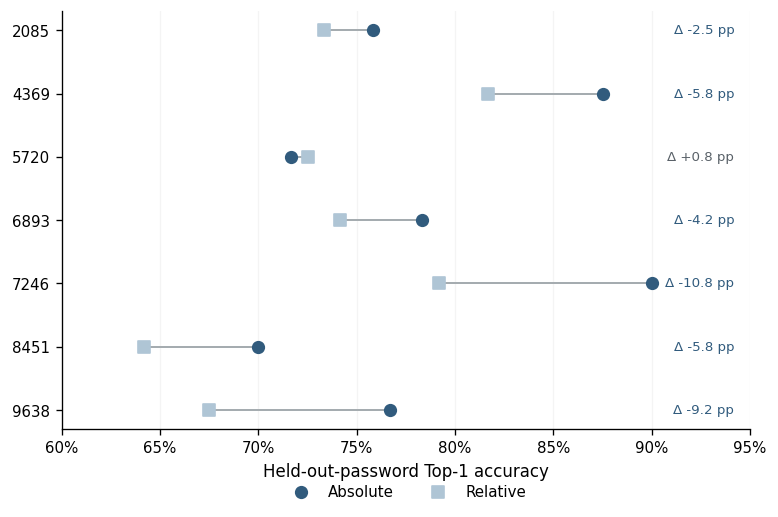

In [52]:
# Figure 1 — paired Top-1 accuracy for each held-out password

password_plot = password_pair.copy()

password_plot[
    "password"
] = [
    batch.split(
        "_",
        1,
    )[1]
    for batch
    in password_plot.index
]

fig, ax = plt.subplots(
    figsize=(7.4, 4.9)
)

y = np.arange(
    len(password_plot)
)

for yi, (_, row) in enumerate(
    password_plot.iterrows()
):
    ax.plot(
        [
            100
            * row[
                "Relative"
            ],
            100
            * row[
                "Absolute"
            ],
        ],
        [
            yi,
            yi,
        ],
        color=MID_GREY,
        linewidth=1.1,
        zorder=1,
    )

ax.scatter(
    100
    * password_plot[
        "Absolute"
    ],
    y,
    s=48,
    color=DARK_BLUE,
    label="Absolute",
    zorder=3,
)

ax.scatter(
    100
    * password_plot[
        "Relative"
    ],
    y,
    s=48,
    marker="s",
    color=LIGHT_BLUE,
    label="Relative",
    zorder=3,
)

for yi, (_, row) in enumerate(
    password_plot.iterrows()
):
    delta_pp = (
        100
        * row[
            "delta_relative_minus_absolute"
        ]
    )

    ax.text(
        94.2,
        yi,
        f"Δ {delta_pp:+.1f} pp",
        ha="right",
        va="center",
        fontsize=8,
        color=(
            DARK_BLUE
            if delta_pp < 0
            else DARK_GREY
        ),
    )

ax.set_yticks(
    y
)

ax.set_yticklabels(
    password_plot[
        "password"
    ]
)

ax.invert_yaxis()

ax.set_xlim(
    60,
    95,
)

ax.set_xlabel(
    "Held-out-password Top-1 accuracy"
)

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, pos: f"{x:.0f}%"
    )
)

ax.grid(
    axis="x",
    alpha=0.13,
)

ax.legend(
    frameon=False,
    ncol=2,
    loc="upper center",
    bbox_to_anchor=(
        0.5,
        -0.10,
    ),
)

fig.subplots_adjust(
    bottom=0.17
)

save_figure(
    fig,
    "RQ7_Fig1_password_paired_top1",
)

plt.show()

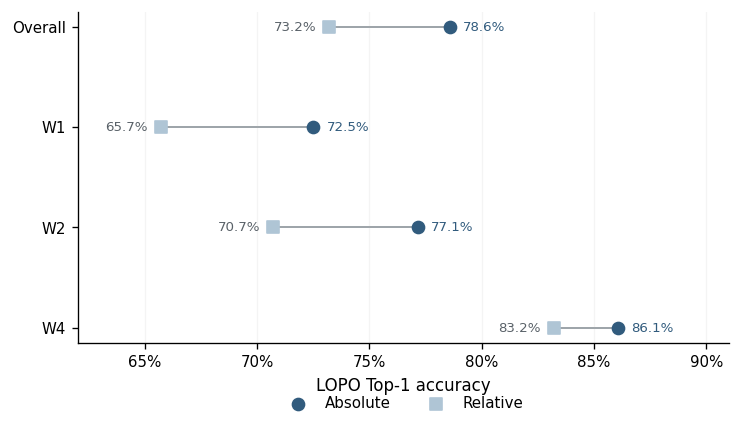

In [53]:
# Figure 2 — overall and wheel-level comparison

scope_order = [
    "Overall",
    "W1",
    "W2",
    "W4",
]

scope_plot = (
    summary[
        summary["scope"]
        .isin(
            scope_order
        )
    ]
    .pivot(
        index="scope",
        columns="representation",
        values="top1",
    )
    .reindex(
        scope_order
    )
)

fig, ax = plt.subplots(
    figsize=(7.0, 4.0)
)

y = np.arange(
    len(scope_order)
)

for yi, scope in enumerate(
    scope_order
):
    row = scope_plot.loc[
        scope
    ]

    ax.plot(
        [
            100
            * row[
                "Relative"
            ],
            100
            * row[
                "Absolute"
            ],
        ],
        [
            yi,
            yi,
        ],
        color=MID_GREY,
        linewidth=1.2,
        zorder=1,
    )

ax.scatter(
    100
    * scope_plot[
        "Absolute"
    ],
    y,
    s=52,
    color=DARK_BLUE,
    label="Absolute",
    zorder=3,
)

ax.scatter(
    100
    * scope_plot[
        "Relative"
    ],
    y,
    s=52,
    marker="s",
    color=LIGHT_BLUE,
    label="Relative",
    zorder=3,
)

for yi, scope in enumerate(
    scope_order
):
    absolute = (
        100
        * scope_plot.loc[
            scope,
            "Absolute",
        ]
    )

    relative = (
        100
        * scope_plot.loc[
            scope,
            "Relative",
        ]
    )

    ax.annotate(
        f"{relative:.1f}%",
        xy=(relative, yi),
        xytext=(-8, 0),
        textcoords="offset points",
        ha="right",
        va="center",
        fontsize=8,
        color=DARK_GREY,
    )

    ax.annotate(
        f"{absolute:.1f}%",
        xy=(absolute, yi),
        xytext=(8, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=8,
        color=DARK_BLUE,
    )

ax.set_yticks(
    y
)

ax.set_yticklabels(
    scope_order
)

ax.invert_yaxis()

ax.set_xlim(
    62,
    91,
)

ax.set_xlabel(
    "LOPO Top-1 accuracy"
)

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, pos: f"{x:.0f}%"
    )
)

ax.grid(
    axis="x",
    alpha=0.13,
)

ax.legend(
    frameon=False,
    ncol=2,
    loc="upper center",
    bbox_to_anchor=(
        0.5,
        -0.12,
    ),
)

fig.subplots_adjust(
    bottom=0.19
)

save_figure(
    fig,
    "RQ7_Fig2_overall_wheel_top1",
)

plt.show()

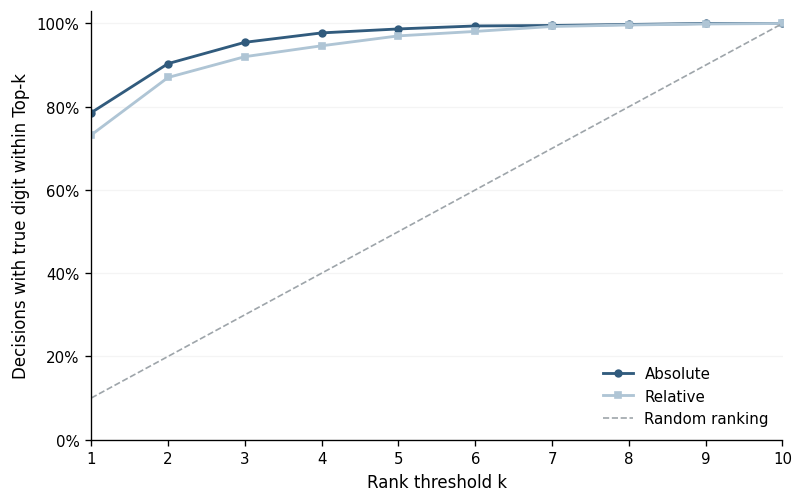

In [54]:
# Figure 3 — complete cumulative true-rank distribution

def cumulative_topk(frame):
    ranks = frame[
        "true_rank"
    ].to_numpy(
        dtype=float
    )

    ks = np.arange(
        1,
        11,
    )

    values = np.array([
        np.mean(
            ranks <= k
        )
        for k
        in ks
    ])

    return (
        ks,
        values,
    )


fig, ax = plt.subplots(
    figsize=(6.8, 4.3)
)

curve_rows = []

for (
    representation,
    color,
    marker,
) in [
    (
        "Absolute",
        DARK_BLUE,
        "o",
    ),
    (
        "Relative",
        LIGHT_BLUE,
        "s",
    ),
]:
    frame = decision_predictions[
        decision_predictions[
            "representation"
        ]
        == representation
    ]

    ks, values = cumulative_topk(
        frame
    )

    ax.plot(
        ks,
        100 * values,
        marker=marker,
        markersize=4,
        linewidth=1.7,
        color=color,
        label=representation,
    )

    for k, value in zip(
        ks,
        values,
    ):
        curve_rows.append({
            "representation": representation,
            "k": int(k),
            "topk_rate": float(value),
        })

ax.plot(
    np.arange(
        1,
        11,
    ),
    10
    * np.arange(
        1,
        11,
    ),
    linestyle="--",
    linewidth=1,
    color=MID_GREY,
    label="Random ranking",
)

ax.set_xlim(
    1,
    10,
)

ax.set_ylim(
    0,
    103,
)

ax.set_xticks(
    np.arange(
        1,
        11,
    )
)

ax.set_yticks(
    np.arange(
        0,
        101,
        20,
    )
)

ax.set_yticklabels([
    f"{value}%"
    for value
    in np.arange(
        0,
        101,
        20,
    )
])

ax.set_xlabel(
    "Rank threshold k"
)

ax.set_ylabel(
    "Decisions with true digit within Top-k"
)

ax.grid(
    axis="y",
    alpha=0.13,
)

ax.legend(
    frameon=False,
    loc="lower right",
)

fig.tight_layout()

save_figure(
    fig,
    "RQ7_Fig3_cumulative_rank",
)

pd.DataFrame(
    curve_rows
).to_csv(
    RESULT_DIR / "RQ7_cumulative_rank_curve.csv",
    index=False,
)

plt.show()

## 9. Tables and result record

In [55]:
candidate_predictions.to_csv(
    RESULT_DIR / "RQ7_candidate_predictions.csv",
    index=False,
)

decision_predictions.to_csv(
    RESULT_DIR / "RQ7_decision_predictions.csv",
    index=False,
)

summary.to_csv(
    RESULT_DIR / "RQ7_summary_metrics.csv",
    index=False,
)

batch_metrics.to_csv(
    RESULT_DIR / "RQ7_batch_metrics.csv",
    index=False,
)


paired_decisions = (
    decision_abs[
        [
            "decision_uid",
            "heldout_batch",
            "wheel",
            "direction",
            "repeat_id",
            "top1_hit",
            "true_rank",
        ]
    ]
    .rename(
        columns={
            "top1_hit": "absolute_top1",
            "true_rank": "absolute_rank",
        }
    )
    .merge(
        decision_rel[
            [
                "decision_uid",
                "top1_hit",
                "true_rank",
            ]
        ].rename(
            columns={
                "top1_hit": "relative_top1",
                "true_rank": "relative_rank",
            }
        ),
        on="decision_uid",
        how="inner",
        validate="one_to_one",
    )
)


discordance = pd.DataFrame([{
    "both_correct": int(
        (
            (
                paired_decisions[
                    "absolute_top1"
                ]
                == 1
            )
            &
            (
                paired_decisions[
                    "relative_top1"
                ]
                == 1
            )
        ).sum()
    ),
    "absolute_only": int(
        (
            (
                paired_decisions[
                    "absolute_top1"
                ]
                == 1
            )
            &
            (
                paired_decisions[
                    "relative_top1"
                ]
                == 0
            )
        ).sum()
    ),
    "relative_only": int(
        (
            (
                paired_decisions[
                    "absolute_top1"
                ]
                == 0
            )
            &
            (
                paired_decisions[
                    "relative_top1"
                ]
                == 1
            )
        ).sum()
    ),
    "both_wrong": int(
        (
            (
                paired_decisions[
                    "absolute_top1"
                ]
                == 0
            )
            &
            (
                paired_decisions[
                    "relative_top1"
                ]
                == 0
            )
        ).sum()
    ),
}])


paired_decisions.to_csv(
    RESULT_DIR / "RQ7_paired_decisions.csv",
    index=False,
)

discordance.to_csv(
    RESULT_DIR / "RQ7_discordance.csv",
    index=False,
)

password_pair.reset_index().to_csv(
    RESULT_DIR / "RQ7_password_pairing.csv",
    index=False,
)

password_rank_pair.reset_index().to_csv(
    RESULT_DIR / "RQ7_password_rank_pairing.csv",
    index=False,
)

paired_tests.to_csv(
    RESULT_DIR / "RQ7_paired_tests.csv",
    index=False,
)


scope_order = [
    "Overall",
    "W1",
    "W2",
    "W4",
]

table1_source = (
    summary[
        summary[
            "scope"
        ].isin(
            scope_order
        )
    ]
    .copy()
)

table1_source[
    "Top-1"
] = (
    100
    * table1_source[
        "top1"
    ]
).map(
    lambda x: f"{x:.1f}%"
)

table1_source[
    "Top-2"
] = (
    100
    * table1_source[
        "top2"
    ]
).map(
    lambda x: f"{x:.1f}%"
)

table1_source[
    "Top-3"
] = (
    100
    * table1_source[
        "top3"
    ]
).map(
    lambda x: f"{x:.1f}%"
)

table1_source[
    "Mean rank"
] = table1_source[
    "mean_true_rank"
].map(
    lambda x: f"{x:.2f}"
)

table1_source[
    "MRR"
] = table1_source[
    "mrr"
].map(
    lambda x: f"{x:.3f}"
)

table1 = table1_source[
    [
        "scope",
        "representation",
        "n_decisions",
        "Top-1",
        "Top-2",
        "Top-3",
        "Mean rank",
        "MRR",
    ]
].rename(
    columns={
        "scope": "Scope",
        "representation": "Representation",
        "n_decisions": "N decisions",
    }
)

table1.to_csv(
    RESULT_DIR / "RQ7_Table1_summary.csv",
    index=False,
)

with open(
    RESULT_DIR / "RQ7_Table1_summary.tex",
    "w",
    encoding="utf-8",
) as f:
    f.write(
        table1.to_latex(
            index=False,
            escape=True,
        )
    )


table2 = password_pair.reset_index().copy()

table2[
    "Password"
] = table2[
    "heldout_batch"
].str.split(
    "_",
    n=1,
).str[1]

table2[
    "Absolute"
] = (
    100
    * table2[
        "Absolute"
    ]
).map(
    lambda x: f"{x:.1f}%"
)

table2[
    "Relative"
] = (
    100
    * table2[
        "Relative"
    ]
).map(
    lambda x: f"{x:.1f}%"
)

table2[
    "Relative − Absolute"
] = (
    100
    * table2[
        "delta_relative_minus_absolute"
    ]
).map(
    lambda x: f"{x:+.1f} pp"
)

table2 = table2[
    [
        "Password",
        "Absolute",
        "Relative",
        "Relative − Absolute",
    ]
]

table2.to_csv(
    RESULT_DIR / "RQ7_Table2_password_pairing.csv",
    index=False,
)

with open(
    RESULT_DIR / "RQ7_Table2_password_pairing.tex",
    "w",
    encoding="utf-8",
) as f:
    f.write(
        table2.to_latex(
            index=False,
            escape=True,
        )
    )

display(table1)
display(table2)

,Scope,Representation,N decisions,Top-1,Top-2,Top-3,Mean rank,MRR
0,Overall,Absolute,840,78.6%,90.4%,95.5%,1.40,0.871
1,W1,Absolute,280,72.5%,86.1%,93.2%,1.56,0.831
2,W2,Absolute,280,77.1%,87.9%,94.3%,1.47,0.858
3,W4,Absolute,280,86.1%,97.1%,98.9%,1.18,0.925
10,Overall,Relative,840,73.2%,87.0%,92.0%,1.59,0.833
11,W1,Relative,280,65.7%,83.9%,90.0%,1.75,0.788
12,W2,Relative,280,70.7%,82.5%,88.9%,1.73,0.810
13,W4,Relative,280,83.2%,94.6%,97.1%,1.30,0.903


representation,Password,Absolute,Relative,Relative − Absolute
0,2085,75.8%,73.3%,-2.5 pp
1,4369,87.5%,81.7%,-5.8 pp
2,5720,71.7%,72.5%,+0.8 pp
3,6893,78.3%,74.2%,-4.2 pp
4,7246,90.0%,79.2%,-10.8 pp
5,8451,70.0%,64.2%,-5.8 pp
6,9638,76.7%,67.5%,-9.2 pp


In [56]:
absolute_top1 = float(
    overall.loc[
        "Absolute",
        "top1",
    ]
)

relative_top1 = float(
    overall.loc[
        "Relative",
        "top1",
    ]
)

delta_top1 = (
    relative_top1
    - absolute_top1
)

conclusion = {
    "research_question": (
        "Is held-out-password true-gate ranking better with absolute 695-D acoustic "
        "features or with a within-scan relative representation?"
    ),
    "analysis_type": (
        "Controlled leave-one-password-out representation ablation"
    ),
    "primary_metric": (
        "10-way decision Top-1 accuracy"
    ),
    "n_passwords": 7,
    "n_decisions_per_representation": 840,
    "absolute_top1": absolute_top1,
    "relative_top1": relative_top1,
    "delta_relative_minus_absolute": float(
        delta_top1
    ),
    "absolute_top2": float(
        overall.loc[
            "Absolute",
            "top2",
        ]
    ),
    "relative_top2": float(
        overall.loc[
            "Relative",
            "top2",
        ]
    ),
    "absolute_top3": float(
        overall.loc[
            "Absolute",
            "top3",
        ]
    ),
    "relative_top3": float(
        overall.loc[
            "Relative",
            "top3",
        ]
    ),
    "absolute_mean_true_rank": float(
        overall.loc[
            "Absolute",
            "mean_true_rank",
        ]
    ),
    "relative_mean_true_rank": float(
        overall.loc[
            "Relative",
            "mean_true_rank",
        ]
    ),
    "passwords_relative_better": int(
        (
            password_pair[
                "delta_relative_minus_absolute"
            ]
            > 0
        ).sum()
    ),
    "passwords_equal": int(
        (
            password_pair[
                "delta_relative_minus_absolute"
            ]
            == 0
        ).sum()
    ),
    "passwords_absolute_better": int(
        (
            password_pair[
                "delta_relative_minus_absolute"
            ]
            < 0
        ).sum()
    ),
    "password_level_top1_wilcoxon_p": float(
        top1_test.pvalue
    ),
    "password_level_mean_rank_wilcoxon_p": float(
        rank_test.pvalue
    ),
    "decision_level_discordance": (
        discordance.iloc[0]
        .to_dict()
    ),
    "interpretation": (
        "Absolute acoustic features outperform the within-scan relative representation "
        "under the fixed LOPO logistic-ranker test. Top-1 falls from 78.6% to 73.2% "
        "after relative normalisation, and Absolute performs better on six of the seven "
        "held-out passwords. Mean true rank also worsens from 1.40 to 1.59. The result "
        "therefore does not support the hypothesis that removing scan-level absolute "
        "offset and scale improves password generalisation in this experiment."
    ),
    "limitation": (
        "The result does not prove that absolute acoustic identity is a causal true-gate "
        "mechanism. Absolute features may contain a mixture of transferable physical "
        "information and correlated wheel/session fingerprints. The seven passwords are "
        "the independent password-level test units, and the fixed logistic ranker is an "
        "ablation tool rather than MAIN-model performance."
    ),
    "decision": (
        "Do not discard absolute acoustic information based on the shortcut concern alone. "
        "Carry both the performance result and the fingerprint-validity risk forward; "
        "subsequent localisation and controlled shortcut tests must determine which parts "
        "of the absolute representation are physically defensible."
    ),
    "next_step": (
        "RQ8 localises where within the one-digit movement the discriminative information occurs."
    ),
}

with open(
    RESULT_DIR / "RQ7_conclusion.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        conclusion,
        f,
        indent=2,
    )


run_info = {
    "notebook": (
        "07_RQ7_Absolute_vs_Relative.ipynb"
    ),
    "batches": BATCHES,
    "passwords": [
        batch.split(
            "_",
            1,
        )[1]
        for batch in BATCHES
    ],
    "feature_count": 695,
    "feature_source": (
        "Frozen B01-B07 695-D full-movement feature caches"
    ),
    "split": (
        "Leave-one-password-out"
    ),
    "domains": (
        "Separate model per wheel and direction; A/B repeats pooled for fitting "
        "but evaluated as separate 10-candidate decisions"
    ),
    "classifier": {
        "type": "LogisticRegression",
        "C": LOGREG_C,
        "solver": "liblinear",
        "class_weight": "balanced",
        "random_state": RANDOM_STATE,
    },
    "representations": {
        "Absolute": (
            "Raw recovered 695-D features + training-fold StandardScaler"
        ),
        "Relative": (
            "Within-decision median/MAD normalisation, std fallback, [-12,12] clip, "
            "then training-fold StandardScaler"
        ),
    },
    "primary_inference": (
        "Two-sided paired Wilcoxon across seven held-out passwords"
    ),
}

with open(
    RESULT_DIR / "RQ7_run_info.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        run_info,
        f,
        indent=2,
    )

print(
    json.dumps(
        conclusion,
        indent=2,
    )
)

print("\nSaved outputs:")
for path in sorted(
    RESULT_DIR.glob(
        "RQ7_*"
    )
):
    print(
        " -",
        path.name,
    )

{
  "research_question": "Is held-out-password true-gate ranking better with absolute 695-D acoustic features or with a within-scan relative representation?",
  "analysis_type": "Controlled leave-one-password-out representation ablation",
  "primary_metric": "10-way decision Top-1 accuracy",
  "n_passwords": 7,
  "n_decisions_per_representation": 840,
  "absolute_top1": 0.7857142857142857,
  "relative_top1": 0.7321428571428571,
  "delta_relative_minus_absolute": -0.0535714285714286,
  "absolute_top2": 0.9035714285714286,
  "relative_top2": 0.8702380952380953,
  "absolute_top3": 0.9547619047619048,
  "relative_top3": 0.9202380952380952,
  "absolute_mean_true_rank": 1.4047619047619047,
  "relative_mean_true_rank": 1.5916666666666666,
  "passwords_relative_better": 1,
  "passwords_equal": 0,
  "passwords_absolute_better": 6,
  "password_level_top1_wilcoxon_p": 0.03125,
  "password_level_mean_rank_wilcoxon_p": 0.015625,
  "decision_level_discordance": {
    "both_correct": 567,
    "absolu